In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('dengue.csv')

In [3]:
df.head()

,Year,Province,District,Latitude,Longitude,Elevation,Month,Cases,Temp_avg,Precipitation_avg,Humidity_avg
0,2019,Western,Colombo,6.924429,79.90725,4,1,1225,26.914286,0.771429,72.607143
1,2019,Western,Gampaha,7.065026,79.96622,19,1,724,27.417857,0.728571,69.892857
2,2019,Western,Kalutara,6.572935,80.02519,5,1,372,26.112500,1.396429,80.464286
3,2019,Central,Kandy,7.275923,80.62659,499,1,288,22.067857,1.853571,83.428571
4,2019,Central,Matale,7.486819,80.52632,362,1,62,25.592857,0.850000,74.285714


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               900 non-null    int64  
 1   Province           900 non-null    object 
 2   District           900 non-null    object 
 3   Latitude           900 non-null    float64
 4   Longitude          900 non-null    float64
 5   Elevation          900 non-null    int64  
 6   Month              900 non-null    int64  
 7   Cases              900 non-null    int64  
 8   Temp_avg           899 non-null    float64
 9   Precipitation_avg  899 non-null    float64
 10  Humidity_avg       899 non-null    float64
dtypes: float64(5), int64(4), object(2)
memory usage: 77.5+ KB


In [5]:
df.isnull().sum()

,0
Year,0
Province,0
District,0
Latitude,0
Longitude,0
Elevation,0
Month,0
Cases,0
Temp_avg,1
Precipitation_avg,1


In [6]:
df.dropna(inplace=True)
df.isnull().sum()

,0
Year,0
Province,0
District,0
Latitude,0
Longitude,0
Elevation,0
Month,0
Cases,0
Temp_avg,0
Precipitation_avg,0


In [7]:
#for years 2019,20,21
district_monthly_avg_cases = (
    df.groupby(['District', 'Year'])['Cases']
      .mean()
      .reset_index())


district_monthly_avg_cases.head(30)

,District,Year,Cases
0,Ampara,2019,159.000000
1,Ampara,2020,108.083333
2,Ampara,2021,35.166667
3,Anuradhapura,2019,97.000000
4,Anuradhapura,2020,36.083333
5,Anuradhapura,2021,31.000000
6,Badulla,2019,160.166667
7,Badulla,2020,43.750000
8,Badulla,2021,63.583333
9,Batticaloa,2019,237.333333


In [8]:
#sum of 3 years
district_yearly_avg_cases = (
    district_monthly_avg_cases
    .groupby('District')['Cases']
    .mean()
    .reset_index())

district_yearly_avg_cases


,District,Cases
0,Ampara,100.750000
1,Anuradhapura,54.694444
2,Badulla,89.166667
3,Batticaloa,280.000000
4,Colombo,1010.444444
5,Galle,271.111111
6,Gampaha,738.810606
7,Hambantota,80.111111
8,Jaffna,294.194444
9,Kalutara,362.250000


In [9]:
#province

In [10]:
# Get the unique District to Province mapping from the original 'df' DataFrame
district_province_map = df[['District', 'Province']].drop_duplicates()

# Merge this mapping into district_year_cases to add the 'Province' column
district_year_cases_with_province = pd.merge(
    district_yearly_avg_cases,
    district_province_map,
    on='District',
    how='left'
)
district_year_cases_with_province.head()


,District,Cases,Province
0,Ampara,100.750000,Eastern
1,Anuradhapura,54.694444,North central
2,Badulla,89.166667,Uva
3,Batticaloa,280.000000,Eastern
4,Colombo,1010.444444,Western


In [11]:

# Now, group by 'Province' using the DataFrame that includes 'Province'
province_total_cases = (
    district_year_cases_with_province
    .groupby('Province')['Cases']
    .sum()
    .reset_index(name='total_cases')
)
province_total_cases

,Province,total_cases
0,Central,497.638889
1,Eastern,535.361111
2,North Western,264.583333
3,North central,80.694444
4,Northern,373.111111
5,Sabaragamuwa,316.055556
6,Southern,499.888889
7,Uva,103.972222
8,Western,2111.505051


In [12]:
population = {
    'Western': 6149000,
    'Central': 2766000,
    'Southern': 2654000,
    'Northern': 1143000,
    'Eastern': 1729000,
    'North Western': 2551000,
    'North central': 1377000,
    'Uva': 1376000,
    'Sabaragamuwa': 2058000
}


In [13]:
province_total_cases['Population'] = (
    province_total_cases['Province'].map(population)
)
province_total_cases



,Province,total_cases,Population
0,Central,497.638889,2766000
1,Eastern,535.361111,1729000
2,North Western,264.583333,2551000
3,North central,80.694444,1377000
4,Northern,373.111111,1143000
5,Sabaragamuwa,316.055556,2058000
6,Southern,499.888889,2654000
7,Uva,103.972222,1376000
8,Western,2111.505051,6149000


In [14]:
province_total_cases['incidence_per_100k'] = (
    province_total_cases['total_cases'] /
    province_total_cases['Population']
) * 100000
province_total_cases


,Province,total_cases,Population,incidence_per_100k
0,Central,497.638889,2766000,17.991283
1,Eastern,535.361111,1729000,30.963627
2,North Western,264.583333,2551000,10.371750
3,North central,80.694444,1377000,5.860163
4,Northern,373.111111,1143000,32.643142
5,Sabaragamuwa,316.055556,2058000,15.357413
6,Southern,499.888889,2654000,18.835301
7,Uva,103.972222,1376000,7.556121
8,Western,2111.505051,6149000,34.338999


In [15]:
low_threshold = province_total_cases['incidence_per_100k'].quantile(0.33)
high_threshold = province_total_cases['incidence_per_100k'].quantile(0.66)

low_threshold, high_threshold

def classify_risk(incidence):
    if incidence <= low_threshold:
        return 'Low Risk'
    elif incidence <= high_threshold:
        return 'Medium Risk'
    else:
        return 'High Risk'

province_total_cases['risk_level'] = (
    province_total_cases['incidence_per_100k']
    .apply(classify_risk)
)

province_total_cases[
    ['Province', 'incidence_per_100k', 'risk_level']
]


,Province,incidence_per_100k,risk_level
0,Central,17.991283,Medium Risk
1,Eastern,30.963627,High Risk
2,North Western,10.371750,Low Risk
3,North central,5.860163,Low Risk
4,Northern,32.643142,High Risk
5,Sabaragamuwa,15.357413,Medium Risk
6,Southern,18.835301,Medium Risk
7,Uva,7.556121,Low Risk
8,Western,34.338999,High Risk


/tmp/ipykernel_3451/4227895738.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=province_total_cases['Province'],


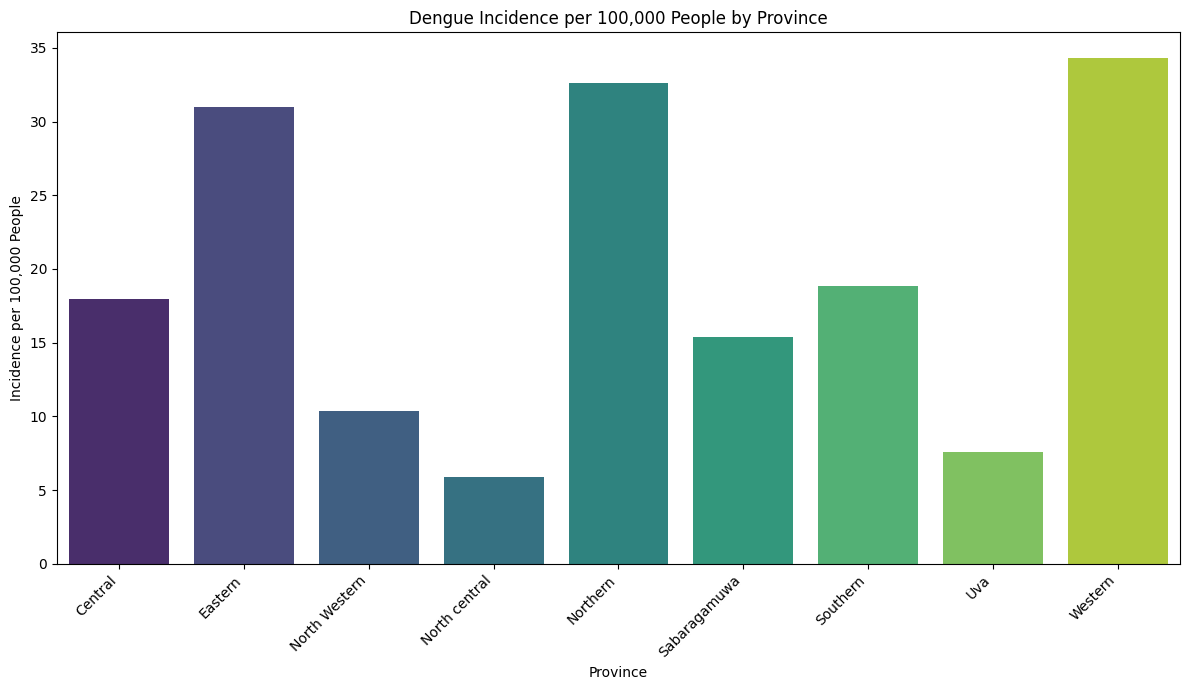

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Incidence per 100k people by Province
plt.figure(figsize=(12, 7))
sns.barplot(x=province_total_cases['Province'],
y=province_total_cases['incidence_per_100k'],
palette='viridis')
plt.title('Dengue Incidence per 100,000 People by Province')
plt.xlabel('Province')
plt.ylabel('Incidence per 100,000 People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
#hypothesis testsing

In [18]:
from scipy.stats import mannwhitneyu

before_2020 = df[df['Year'] < 2020]['Cases']
after_2020 = df[df['Year'] >= 2020]['Cases']

stat, p_value = mannwhitneyu(before_2020, after_2020, alternative='two-sided')

print("Mann-Whitney U statistic:", stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Significant difference in dengue cases before and after 2020.")
else:
    print("No significant difference in dengue cases before and after 2020.")

Mann-Whitney U statistic: 131740.5
p-value: 2.0460713150721646e-30
Significant difference in dengue cases before and after 2020.


In [19]:
#TIME SERIES ANALYSIS

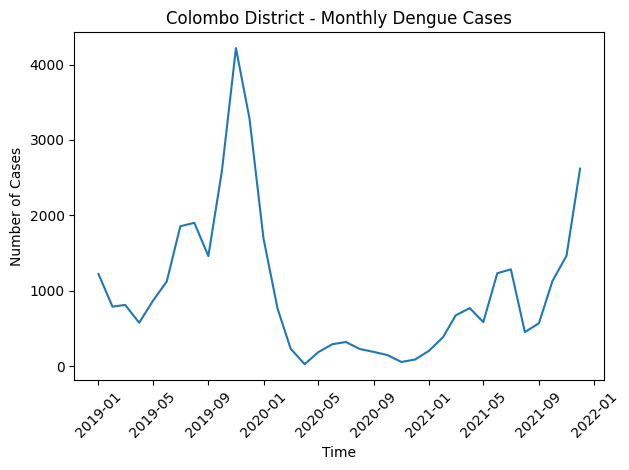

In [20]:
import pandas as pd

# Create proper datetime column
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

# Sort by date
df = df.sort_values('Date')
colombo_data = df[df['District'] == 'Colombo']
colombo_ts = colombo_data.groupby('Date')['Cases'].sum()

import matplotlib.pyplot as plt

plt.figure()
plt.plot(colombo_ts)


plt.title("Colombo District - Monthly Dengue Cases")
plt.xlabel("Time")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(colombo_ts)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

alpha = 0.05
if adf_result[1] < alpha:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary (Trend exists)")

ADF Statistic: -2.476003671409511
p-value: 0.1214225874036804
Series is Non-Stationary (Trend exists)


In [22]:
colombo_diff = colombo_ts.diff().dropna()


In [23]:
from statsmodels.tsa.stattools import adfuller

adf_result_diff = adfuller(colombo_diff)

print("ADF Statistic:", adf_result_diff[0])
print("p-value:", adf_result_diff[1])

if adf_result_diff[1] < 0.05:
    print("Differenced series is Stationary")
else:
    print("Still Non-Stationary")

ADF Statistic: -2.22402331954075
p-value: 0.19764218711952752
Still Non-Stationary


In [24]:
seasonal_diff = colombo_ts.diff(periods=12).dropna()


In [25]:
from statsmodels.tsa.stattools import adfuller

adf_result_diff = adfuller(seasonal_diff)

print("ADF Statistic:", adf_result_diff[0])
print("p-value:", adf_result_diff[1])

if adf_result_diff[1] < 0.05:
    print("Differenced series is Stationary")
else:
    print("Still Non-Stationary")

ADF Statistic: 0.4545564160390412
p-value: 0.9834244271842054
Still Non-Stationary


In [26]:
colombo_diff2 = colombo_diff.diff().dropna()

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(colombo_diff2)
print(adf_result[0])
print(adf_result[1])

-3.9421970118317757
0.0017453390121596366


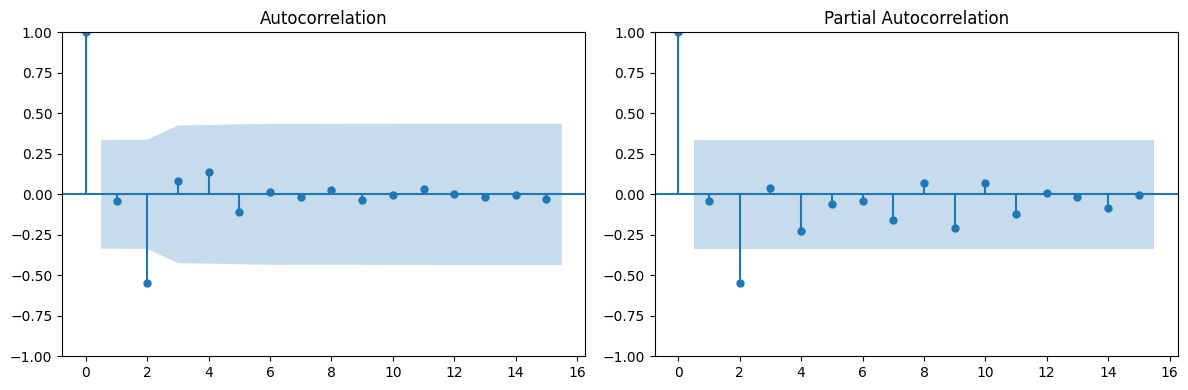

In [27]:
# Step 3: Plot ACF and PACF on stationary data
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(colombo_diff2, lags=15, ax=axes[0])
plot_pacf(colombo_diff2, lags=15, ax=axes[1])
plt.tight_layout()
plt.show()

In [28]:
from statsmodels.tsa.arima.model import ARIMA
import itertools
import warnings
warnings.filterwarnings('ignore')

# Try different p and q combinations
p_values = [0, 1, 2]
q_values = [0, 1, 2]
d = 2

best_aic = float('inf')
best_order = None

for p, q in itertools.product(p_values, q_values):
    try:
        model = ARIMA(colombo_ts, order=(p, d, q))
        result = model.fit()
        print(f"ARIMA({p},{d},{q}) - AIC: {result.aic:.2f}")
        if result.aic < best_aic:
            best_aic = result.aic
            best_order = (p, d, q)
    except:
        continue

print(f"\nBest Model: ARIMA{best_order} with AIC: {best_aic:.2f}")

ARIMA(0,2,0) - AIC: 542.22
ARIMA(0,2,1) - AIC: 539.27
ARIMA(0,2,2) - AIC: 530.04
ARIMA(1,2,0) - AIC: 544.12
ARIMA(1,2,1) - AIC: 536.65
ARIMA(1,2,2) - AIC: 532.03
ARIMA(2,2,0) - AIC: 534.32
ARIMA(2,2,1) - AIC: 536.03
ARIMA(2,2,2) - AIC: 537.85

Best Model: ARIMA(0, 2, 2) with AIC: 530.04


                               SARIMAX Results                                
Dep. Variable:                  Cases   No. Observations:                   36
Model:                 ARIMA(0, 2, 2)   Log Likelihood                -262.020
Date:                Sun, 31 May 2026   AIC                            530.040
Time:                        03:06:00   BIC                            534.619
Sample:                    01-01-2019   HQIC                           531.602
                         - 12-01-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2963      0.227     -1.302      0.193      -0.742       0.150
ma.L2         -0.7036      0.187     -3.754      0.000      -1.071      -0.336
sigma2       2.63e+05   1.05e-06   2.51e+11      0.0

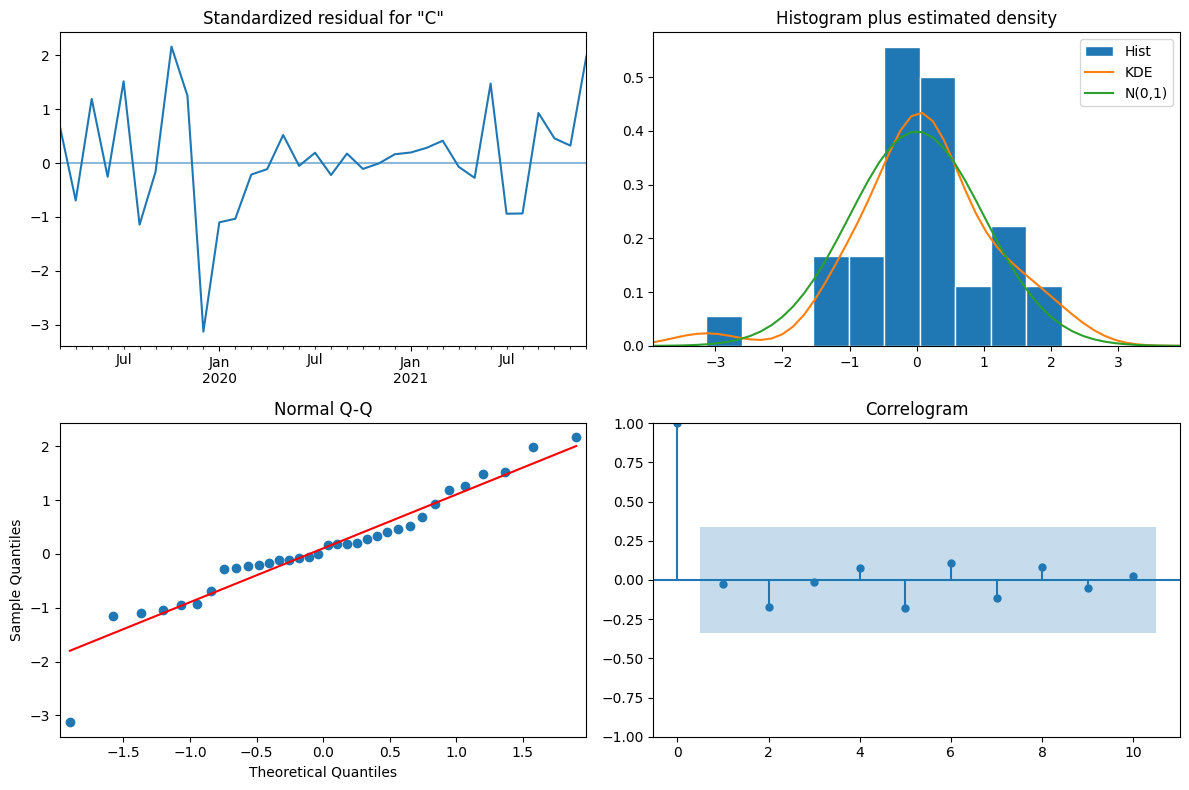


Ljung-Box Test:
      lb_stat  lb_pvalue
10  11.359455   0.330207
6-Month Forecast:
2022-01-01    3384
2022-02-01    3442
2022-03-01    3500
2022-04-01    3558
2022-05-01    3616
2022-06-01    3674
Freq: MS, Name: predicted_mean, dtype: int64


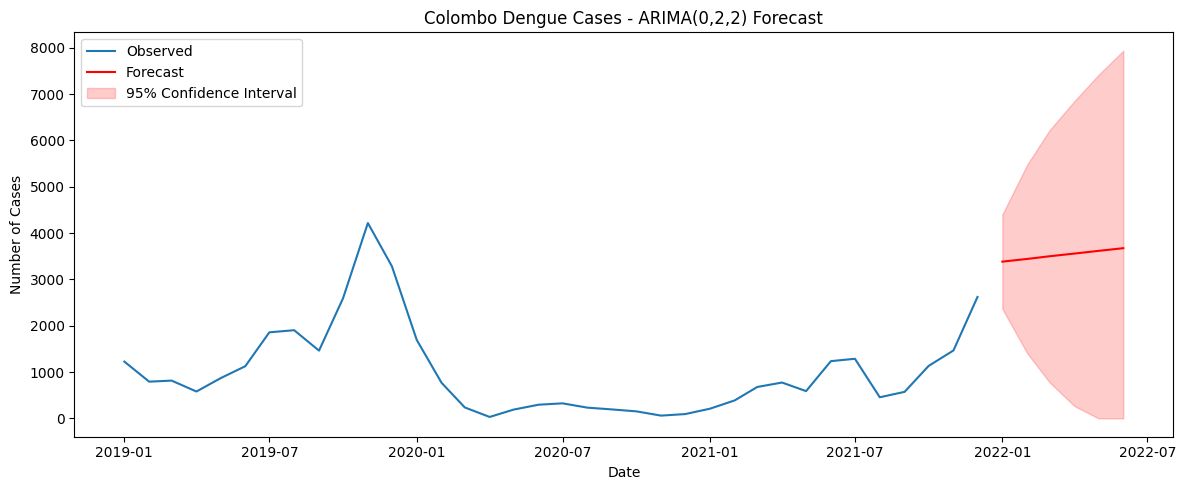

In [29]:
# Fit the best model
best_model = ARIMA(colombo_ts, order=(0, 2, 2))
best_result = best_model.fit()
print(best_result.summary())

# Step 1: Residual Diagnostics
best_result.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

# Step 2: Ljung-Box Test (residuals should be white noise)
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(best_result.resid, lags=[10], return_df=True)
print("\nLjung-Box Test:")
print(lb_test)
# p-value > 0.05 means residuals are white noise (good!)

# Forecast only 6 months
forecast = best_result.get_forecast(steps=6)
forecast_mean = forecast.predicted_mean.clip(lower=0)
forecast_ci = forecast.conf_int()
forecast_ci[forecast_ci < 0] = 0  # clip negatives

print("6-Month Forecast:")
print(forecast_mean.round().astype(int))

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(colombo_ts, label='Observed')
plt.plot(forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 color='red', alpha=0.2, label='95% Confidence Interval')
plt.title("Colombo Dengue Cases - ARIMA(0,2,2) Forecast")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
'''
Forecast interpretation:

The model predicts dengue cases will continue at around 3,300–3,600 cases per month from early to mid 2022
The trend is slightly increasing, which aligns with the upward pattern visible at the end of 2021

'''

'\nForecast interpretation:\n\nThe model predicts dengue cases will continue at around 3,300–3,600 cases per month from early to mid 2022\nThe trend is slightly increasing, which aligns with the upward pattern visible at the end of 2021\n\n'

### Evaluating Forecast Accuracy with Train-Test Split (MAE & RMSE)



In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Define the size of the test set (e.g., last 6 months, matching the forecast steps)
n_test = 6

# Split the data into training and testing sets
train_data = colombo_ts[:-n_test]
test_data = colombo_ts[-n_test:]

print(f"Training data period: {train_data.index.min()} to {train_data.index.max()}")
print(f"Testing data period: {test_data.index.min()} to {test_data.index.max()}")
print(f"Number of training points: {len(train_data)}")
print(f"Number of testing points: {len(test_data)}")

Training data period: 2019-01-01 00:00:00 to 2021-06-01 00:00:00
Testing data period: 2021-07-01 00:00:00 to 2021-12-01 00:00:00
Number of training points: 30
Number of testing points: 6


Re-train the ARIMA model

In [32]:
from statsmodels.tsa.arima.model import ARIMA

# Re-fit the best model on the training data
eval_model = ARIMA(train_data, order=best_order) # best_order was (0,2,2)
eval_result = eval_model.fit()

print("Model re-trained on training data.")

# Generate a forecast for the test period
forecast_eval = eval_result.get_forecast(steps=n_test)
forecast_mean_eval = forecast_eval.predicted_mean.clip(lower=0)

print("\nForecasted values for the test period:")
print(forecast_mean_eval.round().astype(int))

print("\nActual values for the test period:")
print(test_data.round().astype(int))

Model re-trained on training data.

Forecasted values for the test period:
2021-07-01    1756
2021-08-01    1773
2021-09-01    1790
2021-10-01    1808
2021-11-01    1825
2021-12-01    1842
Freq: MS, Name: predicted_mean, dtype: int64

Actual values for the test period:
Date
2021-07-01    1286
2021-08-01     455
2021-09-01     572
2021-10-01    1132
2021-11-01    1466
2021-12-01    2621
Name: Cases, dtype: int64


Finally, we can calculate the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to quantify the accuracy of our forecast on the held-out test data.

Mean Absolute Error (MAE) on test set: 803.19
Root Mean Squared Error (RMSE) on test set: 878.77


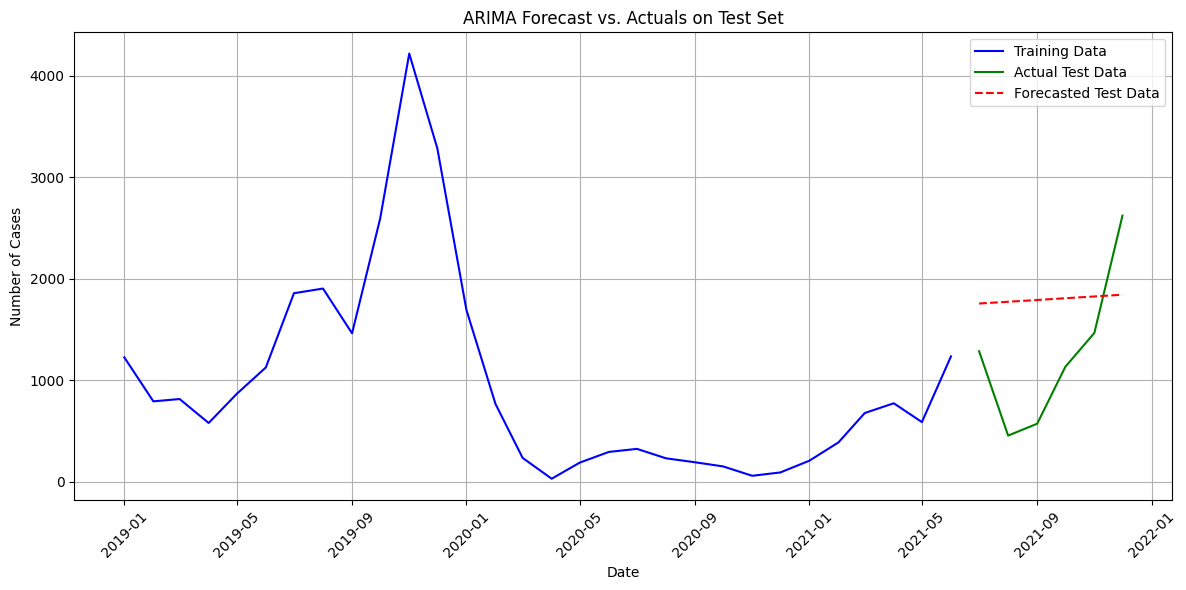

In [33]:
# Calculate MAE and RMSE
mae = mean_absolute_error(test_data, forecast_mean_eval)
rmse = np.sqrt(mean_squared_error(test_data, forecast_mean_eval))

print(f"Mean Absolute Error (MAE) on test set: {mae:.2f}")
print(f"Root Mean Squared Error (RMSE) on test set: {rmse:.2f}")

# Plot the actual vs. forecasted values for the test set
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data, label='Training Data', color='blue')
plt.plot(test_data.index, test_data, label='Actual Test Data', color='green')
plt.plot(forecast_mean_eval.index, forecast_mean_eval, label='Forecasted Test Data', color='red', linestyle='--')
plt.title('ARIMA Forecast vs. Actuals on Test Set')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()